In [1]:
import onnxruntime as ort

In [2]:
import yaml
import numpy as np
import cv2
import os
from PIL import Image
from matplotlib import pyplot as plt

In [3]:
print(ort.__version__)
print(ort.get_available_providers())

1.24.4
['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']


In [4]:
class InferenceRunner:
    def __init__(self):
        self.session = ort.InferenceSession("model.onnx", providers=["CUDAExecutionProvider", "CPUExecutionProvider"])

        self.anchors = np.array([
            [10, 13],
            [16, 30],
            [33, 23]
        ], dtype=np.float32)
        
        self.inputName = self.session.get_inputs()[0].name
        self.outputName = self.session.get_outputs()[0].name
        
        print(self.session.get_inputs()[0].shape)
        print(self.session.get_inputs()[0].type)

    def run(self, image):
        imageT = self.transformImg(image)
        
        output = self.session.run(None, {self.inputName: imageT})
        
        print("Output shape:", [o.shape for o in output])
        pred = output[0]
        
        # sigmoid
        pred[..., 0:2] = 1 / (1 + np.exp(-pred[..., 0:2]))
        pred[..., 4:]  = 1 / (1 + np.exp(-pred[..., 4:]))
        
        # shape
        batch, gridH, gridW, numAnchors, predSize = pred.shape

        gridX, gridY = self.getGridXY(gridW, gridH)        
        bx, by, bw, bh = self.getBorders(numAnchors, pred, gridX, gridY, gridW, gridH)        
        classPred, finalConf = self.getPredConf(pred)

        mask = finalConf > 0.85
        
        bx = bx[mask]
        by = by[mask]
        bw = bw[mask]
        bh = bh[mask]
        scores = finalConf[mask]
        labels = classPred[mask]

        boxes_nms, scores_nms, labels_nms = self.getBatchedNMS(scores, labels, bx, by, bw, bh)
        boxesNP, scoresNP, labelsNP = self.mergeBoxesByLabel(boxes_nms, scores_nms, labels_nms)
        
        print("Boxes:", boxes_nms)
        print("Scores:", scores_nms)
        print("Labels:", labels_nms)
        
        boxesPX = self.getBoxesPx(boxesNP, image)        

        return boxesNP, boxesPX, scoresNP, labelsNP

    def transformImg(self, img):
        image = cv2.resize(img, (512, 512))
        image = image.transpose(2, 0, 1)
        image = image / 255.0
        image = image.astype(np.float32)
        image = np.expand_dims(image, axis=0)

        return image

    def getPredConf(self, pred):
        conf = pred[..., 4]
        classProbs = pred[..., 5:]
        
        classPred = np.argmax(classProbs, axis=-1)
        classConf = np.max(classProbs, axis=-1)
        
        finalConf = conf * classConf
    
        return classPred, finalConf
    
    def getGridXY(self, gridW, gridH):
        gridX = np.tile(np.arange(gridW), (gridH, 1))
        gridY = gridX.T
        
        gridX = gridX.reshape(1, gridH, gridW, 1)
        gridY = gridY.reshape(1, gridH, gridW, 1)
    
        return gridX, gridY
    
    def getBorders(self, numAnchors, pred, gridX, gridY, gridW, gridH):
        anchors = self.anchors.reshape(1, 1, 1, numAnchors, 2)
    
        bx = (pred[..., 0] + gridX) / gridW
        by = (pred[..., 1] + gridY) / gridH
        
        bw = anchors[..., 0] * np.exp(pred[..., 2]) / 512
        bh = anchors[..., 1] * np.exp(pred[..., 3]) / 512
    
        return bx, by, bw, bh

    def nms(self, boxes, scores, iouThresh=0.5):
        x1 = boxes[:, 0]
        y1 = boxes[:, 1]
        x2 = boxes[:, 2]
        y2 = boxes[:, 3]
    
        areas = (x2 - x1) * (y2 - y1)
        order = scores.argsort()[::-1]
    
        keep = []
    
        while order.size > 0:
            i = order[0]
            keep.append(i)
    
            xx1 = np.maximum(x1[i], x1[order[1:]])
            yy1 = np.maximum(y1[i], y1[order[1:]])
            xx2 = np.minimum(x2[i], x2[order[1:]])
            yy2 = np.minimum(y2[i], y2[order[1:]])
    
            w = np.maximum(0, xx2 - xx1)
            h = np.maximum(0, yy2 - yy1)
            inter = w * h
    
            iou = inter / (areas[i] + areas[order[1:]] - inter + 1e-6)
    
            inds = np.where(iou <= iouThresh)[0]
            order = order[inds + 1]
    
        return np.array(keep)
    
    def getBatchedNMS(self, scores, labels, bx, by, bw, bh):
        x1 = bx - bw / 2
        y1 = by - bh / 2
        x2 = bx + bw / 2
        y2 = by + bh / 2
        
        boxes = np.stack([x1, y1, x2, y2], axis=1)
    
        keepAll = []
    
        for cls in np.unique(labels):
            mask = labels == cls
    
            clsBoxes = boxes[mask]
            clsScores = scores[mask]
            clsIdx = np.where(mask)[0]
    
            keep = self.nms(clsBoxes, clsScores, 0.5)
            keepAll.extend(clsIdx[keep])
    
        keepAll = np.array(keepAll, dtype=np.int64)
    
        return boxes[keepAll], scores[keepAll], labels[keepAll]
    
    def getBoxesPx(self, boxes, image):
        if boxes.size == 0:
            return boxes  # return empty safely
    
        h, w, _ = image.shape
    
        boxesPx = boxes.copy()
        boxesPx[:, 0] *= w
        boxesPx[:, 1] *= h
        boxesPx[:, 2] *= w
        boxesPx[:, 3] *= h
    
        return boxesPx.astype(int)
    
    def mergeBoxesByLabel(self, boxes, scores, labels):
        mergedBoxes = []
        mergedScores = []
        mergedLabels = []
    
        for cls in np.unique(labels):
            mask = labels == cls
    
            clsBoxes = boxes[mask]
            clsScores = scores[mask]
    
            if len(clsBoxes) == 0:
                continue
    
            x1 = clsBoxes[:, 0].min()
            y1 = clsBoxes[:, 1].min()
            x2 = clsBoxes[:, 2].max()
            y2 = clsBoxes[:, 3].max()
    
            mergedBoxes.append([x1, y1, x2, y2])
            mergedScores.append(clsScores.max())
            mergedLabels.append(cls)
    
        return (np.array(mergedBoxes), np.array(mergedScores), np.array(mergedLabels))
               

In [5]:
cv2Img = cv2.imread(r"C:\PROJECTS\TrafficLightDetectionTutorial\TrainData\test\images\0453.png")
image = cv2.cvtColor(cv2Img, cv2.COLOR_BGR2RGB)

In [6]:
infRunner = InferenceRunner()
boxesNP, boxesPX, scoresNP, labelsNP = infRunner.run(image)

['batch_size', 3, 512, 512]
tensor(float)
Output shape: [(1, 64, 64, 3, 8)]
Boxes: [[0.43873723 0.49652041 0.45934238 0.52286254]
 [0.46715568 0.51093754 0.48685132 0.53691845]
 [0.4665859  0.49663536 0.48628776 0.52305427]
 [0.43792923 0.48148026 0.45857204 0.50872877]
 [0.452243   0.51036316 0.47249892 0.53668199]
 [0.45179207 0.49645614 0.4726053  0.52349342]
 [0.45234073 0.4818393  0.47195389 0.50854035]
 [0.43806766 0.51043486 0.45910677 0.53643261]
 [0.57893801 0.51123871 0.59973022 0.53791745]
 [0.57864214 0.49676727 0.59915672 0.52411389]
 [0.59375666 0.52596014 0.61388727 0.55224333]
 [0.60698116 0.49602007 0.62738075 0.52417365]
 [0.59321477 0.49719929 0.61392226 0.52414546]
 [0.5932465  0.51034884 0.61404027 0.53700954]
 [0.60710273 0.5110998  0.62760426 0.53773293]
 [0.60826071 0.52423457 0.6295817  0.55502638]]
Scores: [0.9996961  0.99929035 0.99921745 0.99907434 0.9989318  0.99853116
 0.9979186  0.9967391  0.9996237  0.9995749  0.9992699  0.999024
 0.9989011  0.998834   0

In [7]:
img = cv2Img.copy()

for i in range(len(boxesPX)):
    x1, y1, x2, y2 = boxesPX[i]
    score = scoresNP[i]
    label = labelsNP[i]

    print(label)
    
    color = (0, 0, 105)
    if (label == 2):
        color = (0, 105, 0)
    elif (label == 1):
        color = (0, 105, 105)        

    centerPoint = ((x1 + x2) // 2, (y1 + y2) // 2)
    
    cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
    cv2.circle(img, centerPoint, radius=2, color=(0, 0, 0), thickness=-1)

    text = f"{label}"
    text2 = f"{score:.3f}"
        
    cv2.putText(img, text, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, tuple(c * 2 for c in color), 1)
    cv2.putText(img, text2, (x1 - 10, y2 + 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, tuple(c * 2 for c in color), 1)

0
2


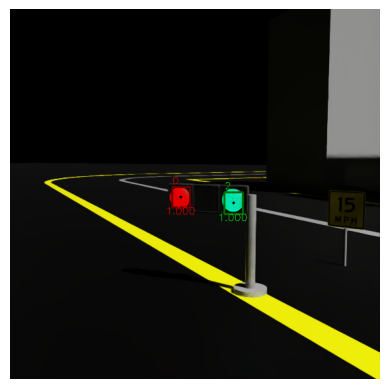

In [8]:
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [9]:
cv2.imwrite("outputONNX.png", img)

True